# Metropolis-Hastings算法可视化

本notebook演示了Metropolis-Hastings (MH)采样算法，这是一种马尔可夫链蒙特卡洛(MCMC)方法，用于在直接采样困难时从概率分布中生成样本。

## 算法概述

Metropolis-Hastings算法的工作原理如下：

1. **初始化**：从样本空间中选择一个初始状态 $x_0$。
2. **提议**：在每一步 $t$，从提议分布 $Q(x'|x_t)$ 中生成一个候选状态 $x'$。
3. **接受概率**：计算接受概率：
   $$
   A(x'|x_t) = \min\left(1, \frac{P(x')Q(x_t|x')}{P(x_t)Q(x'|x_t)}\right)
   $$
   其中 $P(x)$ 是目标分布。
4. **接受/拒绝**：生成一个随机数 $u \sim \text{Uniform}(0,1)$：
   - 如果 $u \leq A(x'|x_t)$，接受候选：$x_{t+1} = x'$
   - 否则，拒绝候选：$x_{t+1} = x_t$
5. **重复**：重复步骤2-4进行大量迭代。

在本notebook中，我们将可视化MH算法如何从提议分布收敛到目标分布。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
import seaborn as sns

# Set style for better visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

# Set random seed for reproducibility
np.random.seed(42)

## 定义目标分布和提议分布

在本演示中，我们将使用双峰目标分布（两个高斯分布的混合）和正态提议分布。

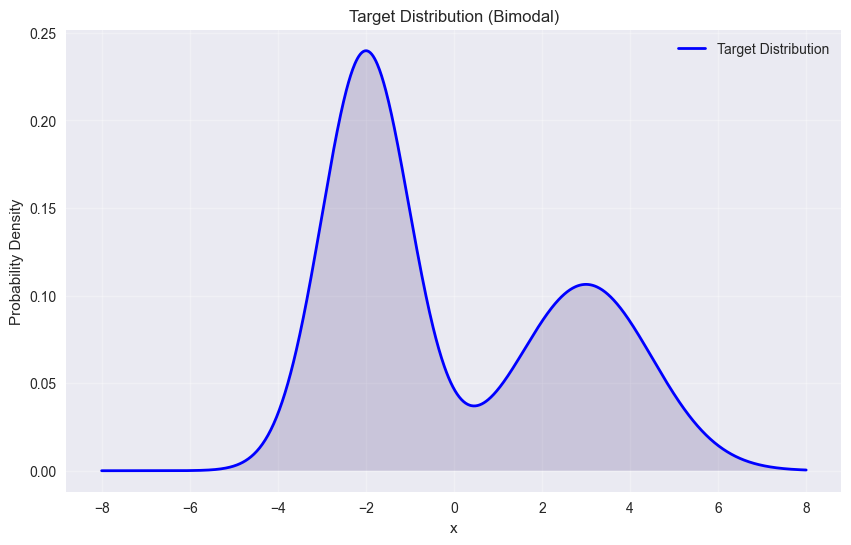

In [2]:
# Define the target distribution (bimodal: mixture of two Gaussians)
def target_distribution(x):
    """Bimodal target distribution: mixture of two Gaussians."""
    return 0.6 * norm.pdf(x, loc=-2, scale=1) + 0.4 * norm.pdf(x, loc=3, scale=1.5)

# Define the proposal distribution (normal distribution)
def proposal_distribution(x, sigma=1.0):
    """Normal proposal distribution centered at x."""
    return np.random.normal(x, sigma)

# Calculate the proposal density (needed for MH acceptance probability)
def proposal_density(x, given_x, sigma=1.0):
    """Density of the proposal distribution."""
    return norm.pdf(x, loc=given_x, scale=sigma)

# Plot the target distribution
x_values = np.linspace(-8, 8, 1000)
y_values = target_distribution(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution')
plt.fill_between(x_values, y_values, alpha=0.2)
plt.title('Target Distribution (Bimodal)')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Metropolis-Hastings算法实现

现在，让我们实现MH算法。我们将跟踪所有样本和接受决策，以便稍后可视化过程。

In [3]:
def metropolis_hastings(target_dist, proposal_func, proposal_density_func, initial_state, n_iterations, sigma=1.0):
    """Implement the Metropolis-Hastings algorithm.
    
    Args:
        target_dist: The target distribution function
        proposal_func: Function to generate proposals
        proposal_density_func: Function to calculate proposal density
        initial_state: Starting point of the chain
        n_iterations: Number of iterations to run
        sigma: Standard deviation for the proposal distribution
        
    Returns:
        samples: Array of samples from the target distribution
        accepted: Boolean array indicating which proposals were accepted
        acceptance_rate: Overall acceptance rate
    """
    samples = np.zeros(n_iterations)
    accepted = np.zeros(n_iterations, dtype=bool)
    samples[0] = initial_state
    
    for i in range(1, n_iterations):
        # Current state
        current_state = samples[i-1]
        
        # Generate a proposal
        proposal = proposal_func(current_state, sigma)
        
        # Calculate acceptance probability
        numerator = target_dist(proposal) * proposal_density_func(current_state, proposal, sigma)
        denominator = target_dist(current_state) * proposal_density_func(proposal, current_state, sigma)
        
        # Avoid division by zero
        if denominator == 0:
            acceptance_prob = 0
        else:
            acceptance_prob = min(1, numerator / denominator)
        
        # Accept or reject the proposal
        u = np.random.uniform(0, 1)
        if u <= acceptance_prob:
            samples[i] = proposal
            accepted[i] = True
        else:
            samples[i] = current_state
            accepted[i] = False
    
    acceptance_rate = np.mean(accepted)
    return samples, accepted, acceptance_rate

## 运行算法并收集样本

让我们运行MH算法并收集样本。我们将使用合理的迭代次数以确保收敛。

In [4]:
# Parameters for the MH algorithm
initial_state = 0.0  # Starting point
n_iterations = 5000  # Number of iterations
sigma = 2.0  # Standard deviation for the proposal distribution

# Run the MH algorithm
samples, accepted, acceptance_rate = metropolis_hastings(
    target_distribution, 
    proposal_distribution, 
    proposal_density,
    initial_state, 
    n_iterations,
    sigma
)

print(f"Acceptance rate: {acceptance_rate:.2f}")
print(f"Number of accepted samples: {np.sum(accepted)}")
print(f"Number of rejected samples: {np.sum(~accepted)}")

Acceptance rate: 0.66
Number of accepted samples: 3314
Number of rejected samples: 1686


## 可视化采样过程

现在，让我们可视化采样过程。我们将创建一个动画，展示样本如何随时间累积，以及样本的直方图如何收敛到目标分布。

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


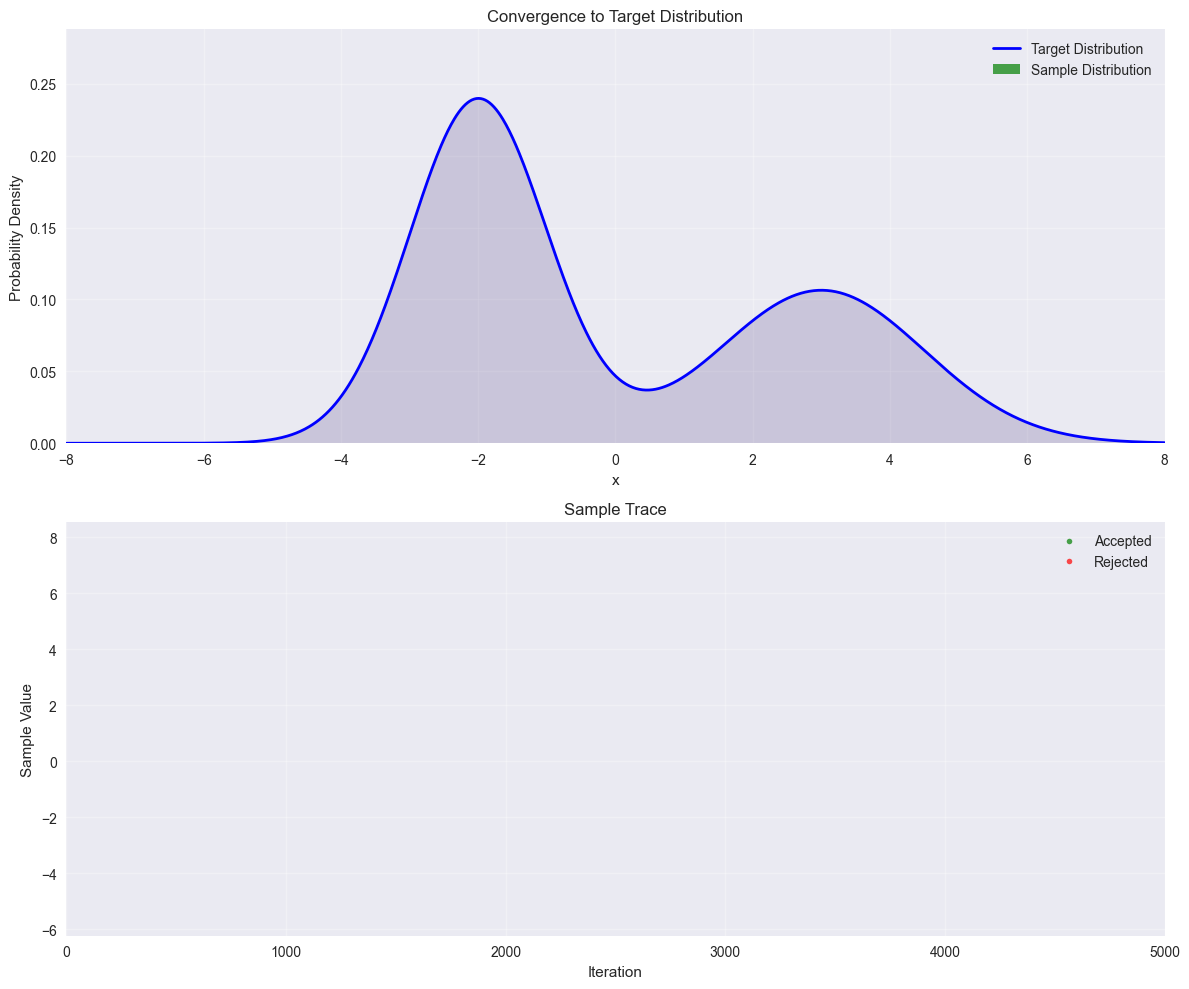

In [5]:
# Create a figure for the animation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3)

# Plot the target distribution
x_values = np.linspace(-8, 8, 1000)
y_values = target_distribution(x_values)
ax1.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution')
ax1.fill_between(x_values, y_values, alpha=0.2)

# Initialize the histogram
n_bins = 50
hist, bins, _ = ax1.hist([], bins=n_bins, density=True, alpha=0.7, color='green', label='Sample Distribution')

# Initialize the trace plot
line, = ax2.plot([], [], 'r-', linewidth=1, alpha=0.7)
points_accepted, = ax2.plot([], [], 'go', markersize=4, alpha=0.7, label='Accepted')
points_rejected, = ax2.plot([], [], 'ro', markersize=4, alpha=0.7, label='Rejected')

# Set up the axes
ax1.set_xlim(-8, 8)
ax1.set_ylim(0, max(y_values) * 1.2)
ax1.set_title('Convergence to Target Distribution')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlim(0, n_iterations)
ax2.set_ylim(min(samples) - 1, max(samples) + 1)
ax2.set_title('Sample Trace')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Sample Value')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Animation update function
def update(frame):
    # Update the histogram
    ax1.clear()
    ax1.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution')
    ax1.fill_between(x_values, y_values, alpha=0.2)
    
    # Use samples up to the current frame
    current_samples = samples[:frame+1]
    ax1.hist(current_samples, bins=n_bins, density=True, alpha=0.7, color='green', label='Sample Distribution')
    
    ax1.set_xlim(-8, 8)
    ax1.set_ylim(0, max(y_values) * 1.2)
    ax1.set_title(f'Convergence to Target Distribution (Iteration: {frame+1})')
    ax1.set_xlabel('x')
    ax1.set_ylabel('Probability Density')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Update the trace plot
    iterations = np.arange(frame + 1)
    line.set_data(iterations, current_samples)
    
    # Update the points
    accepted_indices = np.where(accepted[:frame+1])[0]
    rejected_indices = np.where(~accepted[:frame+1])[0]
    
    if len(accepted_indices) > 0:
        points_accepted.set_data(accepted_indices, samples[accepted_indices])
    else:
        points_accepted.set_data([], [])
        
    if len(rejected_indices) > 0:
        points_rejected.set_data(rejected_indices, samples[rejected_indices])
    else:
        points_rejected.set_data([], [])
    
    return line, points_accepted, points_rejected

# Create the animation
ani = FuncAnimation(fig, update, frames=range(0, n_iterations, 20), 
                    blit=False, interval=50, repeat=True)

plt.tight_layout()
plt.show()

## 分析结果

让我们通过比较最终样本分布与目标分布，并检查样本的自相关性来分析MH算法的结果。

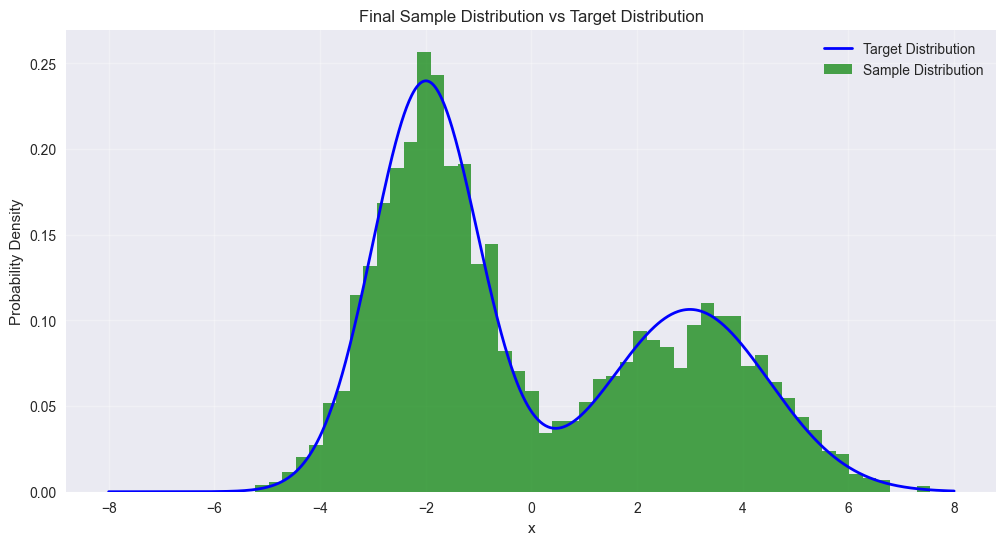

TypeError: stem() got an unexpected keyword argument 'use_line_collection'

<Figure size 1200x600 with 0 Axes>

In [6]:
# Plot the final histogram vs target distribution
plt.figure(figsize=(12, 6))

# Plot the target distribution
x_values = np.linspace(-8, 8, 1000)
y_values = target_distribution(x_values)
plt.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution')

# Plot the histogram of samples
plt.hist(samples, bins=50, density=True, alpha=0.7, color='green', label='Sample Distribution')

plt.title('Final Sample Distribution vs Target Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate and plot the autocorrelation
def autocorrelation(x, max_lag=100):
    """Calculate the autocorrelation of a time series."""
    n = len(x)
    mean = np.mean(x)
    var = np.var(x)
    
    acf = np.zeros(max_lag)
    for lag in range(max_lag):
        if lag == 0:
            acf[lag] = 1.0
        else:
            acf[lag] = np.sum((x[:n-lag] - mean) * (x[lag:] - mean)) / ((n - lag) * var)
    
    return acf

# Calculate autocorrelation
max_lag = 100
acf = autocorrelation(samples, max_lag)

# Plot autocorrelation
plt.figure(figsize=(12, 6))
plt.stem(range(max_lag), acf)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.title('Autocorrelation of Samples')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.grid(True, alpha=0.3)
plt.show()

# Print some statistics
print(f"Sample mean: {np.mean(samples):.4f}")
print(f"Sample standard deviation: {np.std(samples):.4f}")
print(f"Effective sample size (approximate): {len(samples) / (1 + 2 * np.sum(acf[1:])):.1f}")

## Burn-in和Thinning

在MCMC方法中，我们通常需要丢弃初始样本（burn-in），并可能对链进行thinning以减少自相关性。让我们检查这些技术的效果。

In [ ]:
# Determine burn-in period
burn_in = 1000  # Discard the first 1000 samples
thinning = 5    # Keep every 5th sample after burn-in

# Apply burn-in and thinning
thinned_samples = samples[burn_in::thinning]
print(f"Original sample size: {len(samples)}")
print(f"Sample size after burn-in and thinning: {len(thinned_samples)}")

# Plot the original and processed samples
plt.figure(figsize=(12, 6))

# Plot the target distribution
x_values = np.linspace(-8, 8, 1000)
y_values = target_distribution(x_values)
plt.plot(x_values, y_values, 'b-', linewidth=2, label='Target Distribution')

# Plot the histogram of original samples
plt.hist(samples, bins=50, density=True, alpha=0.5, color='green', label='Original Samples')

# Plot the histogram of thinned samples
plt.hist(thinned_samples, bins=50, density=True, alpha=0.7, color='red', label='Thinned Samples')

plt.title('Effect of Burn-in and Thinning')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate autocorrelation for thinned samples
acf_thinned = autocorrelation(thinned_samples, max_lag)

# Plot autocorrelation comparison
plt.figure(figsize=(12, 6))
plt.stem(range(max_lag), acf, linefmt='g-', markerfmt='go', label='Original Samples')
plt.stem(range(max_lag), acf_thinned, linefmt='r-', markerfmt='ro', label='Thinned Samples')
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.title('Autocorrelation Comparison')
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print statistics for thinned samples
print(f"Thinned sample mean: {np.mean(thinned_samples):.4f}")
print(f"Thinned sample standard deviation: {np.std(thinned_samples):.4f}")
print(f"Effective sample size (approximate): {len(thinned_samples) / (1 + 2 * np.sum(acf_thinned[1:])):.1f}")

## 结论

在本notebook中，我们演示了用于从双峰目标分布中采样的Metropolis-Hastings算法。我们可视化了：

1. 样本分布随时间收敛到目标分布的过程
2. 样本轨迹，显示接受和拒绝的提议
3. 样本中的自相关性
4. Burn-in和thinning对减少自相关性的影响

关键观察：
- MH算法成功收敛到目标分布，即使它是双峰的
- 接受率是合理的（通常认为0.2-0.5左右是好的）
- 样本中存在显著的自相关性，这对MCMC方法是典型的
- Burn-in和thinning可以帮助减少自相关性并提高有效样本大小

Metropolis-Hastings算法是从复杂分布中采样的强大工具，这个可视化有助于理解它在实践中的工作原理。